In [4]:
import awkward as ak
import glob
import tqdm
import matplotlib.pyplot as plt
import numpy as np
import mplhep
import boost_histogram as bh
import vector
import matplotlib

In [5]:
titles_z = "z_tautau"
titles_zh = "z_qq"

In [6]:
def to_bh(data, bins, cumulative=False):
    h1 = bh.Histogram(bh.axis.Variable(bins))
    h1.fill(data)
    if cumulative:
        h1[:] = np.sum(h1.values()) - np.cumsum(h1)
    return h1


def to_p4(p4_obj):
    return vector.awk(
        ak.zip(
            {
                "mass": p4_obj.tau,
                "x": p4_obj.x,
                "y": p4_obj.y,
                "z": p4_obj.z,
            }
        )
    )

In [70]:
def load_sample(path, max_files):
    columns = [
        #basic reco inputs
        "reco_jet_p4s",
        "reco_cand_p4s",
        "reco_cand_charge",
        "reco_cand_pdg",

        #advanced reco inputs: tracking variables
        "reco_cand_dz",
        "reco_cand_dz_err",
        "reco_cand_d3",
        "reco_cand_d3_err",
        "reco_cand_z0",
        "reco_cand_z0_err",
        "reco_cand_d0",
        "reco_cand_d0_err",

        #targets
        "gen_jet_p4s",
        "gen_jet_tau_p4s", #tau visible momentum
        "gen_jet_tau_decaymode",
        "gen_jet_full_tau_p4s" #tau full momentum, for debugging
    ]
    data = []
    for fi in tqdm.tqdm(list(glob.glob(path + "/*.parquet"))[:max_files]):
        ret = ak.from_parquet(fi, columns=columns)
        ret = ak.Array({k: ret[k] for k in ret.fields})
        ret = ret[to_p4(ret["gen_jet_p4s"]).pt>0]
        data.append(ret)
    data = ak.concatenate(data)
    return data

In [71]:
data_z = load_sample("/local/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/p8_ee_Z_tautau_ecm91/", -1)

100%|███████████████████████████████████████████████████████████████████| 49/49 [00:01<00:00, 26.11it/s]


In [72]:
data_zh = load_sample("/local/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/p8_ee_Z_qq_ecm91/", -1)

100%|███████████████████████████████████████████████████████████████████| 49/49 [00:02<00:00, 20.18it/s]


In [73]:
len(data_z), len(data_zh)

(126883, 828443)

Text(0, 0.5, 'Number of gen jets / bin')

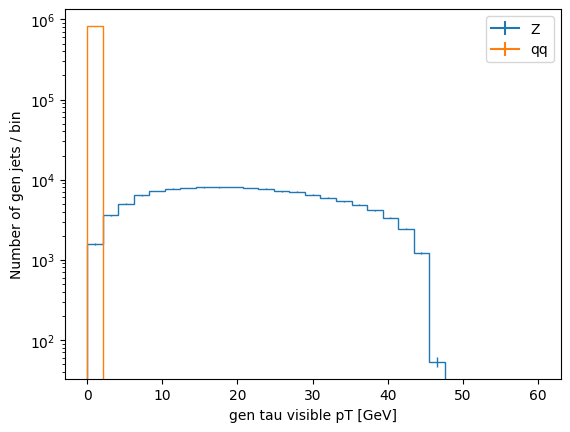

In [76]:
bins = np.linspace(0,60,30)
mplhep.histplot(to_bh(to_p4(data_z["gen_jet_tau_p4s"]).pt, bins=bins), histtype="step", lw=1, flow="sum", label="Z")
mplhep.histplot(to_bh(to_p4(data_zh["gen_jet_tau_p4s"]).pt, bins=bins), histtype="step", lw=1, flow="sum", label="qq")
#mplhep.histplot(to_bh(to_p4(data_qq["gen_jet_tau_p4s"]).pt, bins=bins), histtype="step", lw=2, flow="sum", label="qq")
plt.legend(loc="best")
plt.yscale("log")
plt.xlabel("gen tau visible pT [GeV]")
plt.ylabel("Number of gen jets / bin")
# plt.savefig("gen_tau_visible_pT.png", bbox_inches='tight')

Text(0, 0.5, 'Number of gen jets / bin')

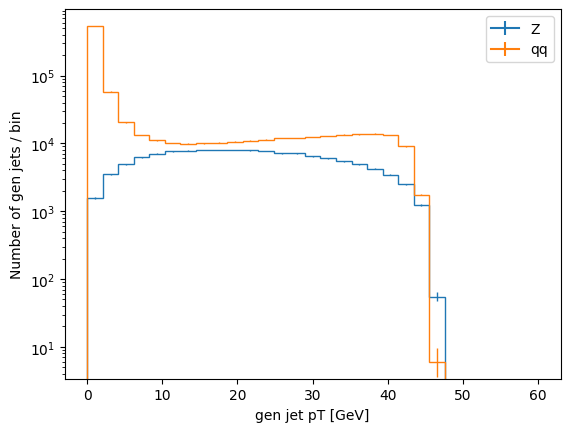

In [77]:
bins = np.linspace(0,60,30)
mplhep.histplot(to_bh(to_p4(data_z["gen_jet_p4s"]).pt, bins=bins), histtype="step", lw=1, flow="sum", label="Z")
mplhep.histplot(to_bh(to_p4(data_zh["gen_jet_p4s"]).pt, bins=bins), histtype="step", lw=1, flow="sum", label="qq")
# mplhep.histplot(to_bh(to_p4(data_qq["gen_jet_p4s"]).pt, bins=bins), histtype="step", lw=1, flow="sum", label="qq")
plt.legend(loc="best")
plt.yscale("log")
plt.xlabel("gen jet pT [GeV]")
plt.ylabel("Number of gen jets / bin")
# plt.savefig("gen_jet_pT.png", bbox_inches='tight')

Text(0, 0.5, 'Number of gen jets / bin')

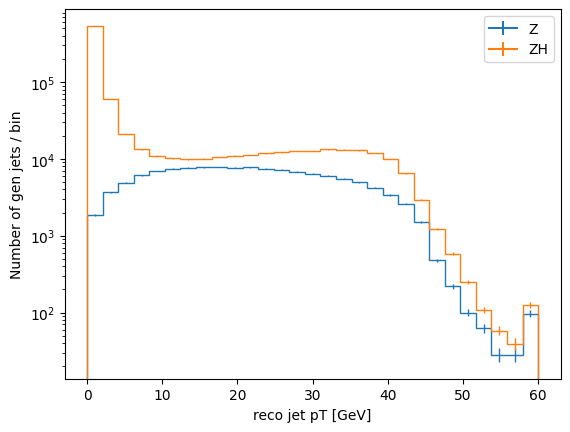

In [78]:
bins = np.linspace(0,60,30)
mplhep.histplot(to_bh(to_p4(data_z["reco_jet_p4s"]).pt, bins=bins), histtype="step", lw=1, flow="sum", label="Z")
mplhep.histplot(to_bh(to_p4(data_zh["reco_jet_p4s"]).pt, bins=bins), histtype="step", lw=1, flow="sum", label="ZH")
# mplhep.histplot(to_bh(to_p4(data_qq["reco_jet_p4s"]).pt, bins=bins), histtype="step", lw=1, flow="sum", label="qq")
plt.legend(loc="best")
plt.yscale("log")
plt.xlabel("reco jet pT [GeV]")
plt.ylabel("Number of gen jets / bin")
# plt.savefig("reco_jet_pT.png", bbox_inches='tight')

Text(0, 0.5, 'reco jet pt')

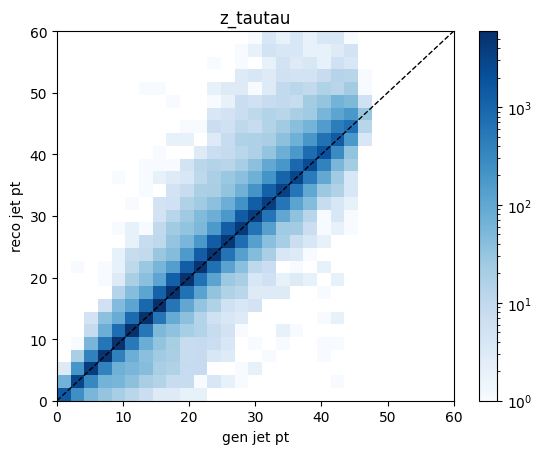

In [79]:
b = np.linspace(0,60,30)
plt.title(titles_z)
plt.hist2d(
    ak.to_numpy(to_p4(data_z["gen_jet_p4s"]).pt),
    ak.to_numpy(to_p4(data_z["reco_jet_p4s"]).pt),
    bins=(b,b),
    norm=matplotlib.colors.LogNorm(),
    cmap="Blues",
);
plt.colorbar()
plt.plot([0,220],[0,220], color="black", ls="--", lw=1.0)
plt.xlabel("gen jet pt")
plt.ylabel("reco jet pt")
# plt.savefig("zz_gen_jet_reco_jet_pT.png", bbox_inches='tight')

Text(0, 0.5, 'reco jet pt')

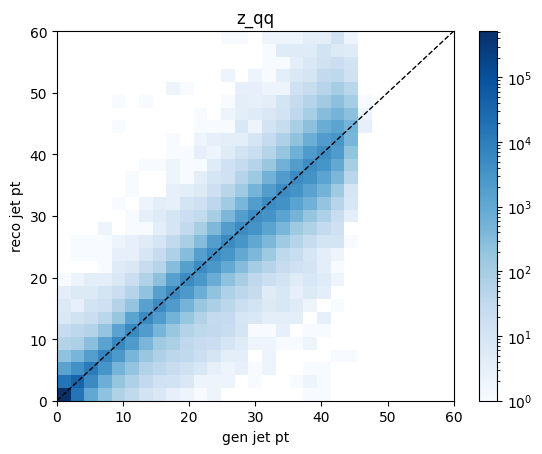

In [80]:
b = np.linspace(0,60,30)
plt.title(titles_zh)
plt.hist2d(
    ak.to_numpy(to_p4(data_zh["gen_jet_p4s"]).pt),
    ak.to_numpy(to_p4(data_zh["reco_jet_p4s"]).pt),
    bins=(b,b),
    norm=matplotlib.colors.LogNorm(),
    cmap="Blues",
);
plt.colorbar()
plt.plot([0,220],[0,220], color="black", ls="--", lw=1.0)
plt.xlabel("gen jet pt")
plt.ylabel("reco jet pt")
# plt.savefig("zh_gen_jet_reco_jet_pT.png", bbox_inches='tight')

Text(0, 0.5, 'reco jet pt')

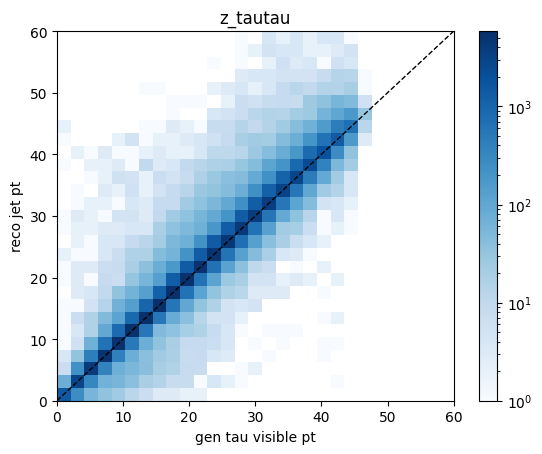

In [81]:
b = np.linspace(0,60,30)
plt.title(titles_z)
plt.hist2d(
    ak.to_numpy(to_p4(data_z["gen_jet_tau_p4s"]).pt),
    ak.to_numpy(to_p4(data_z["reco_jet_p4s"]).pt),
    bins=(b,b),
    norm=matplotlib.colors.LogNorm(),
    cmap="Blues",
);
plt.colorbar()
plt.plot([0,220],[0,220], color="black", ls="--", lw=1.0)
plt.xlabel("gen tau visible pt")
plt.ylabel("reco jet pt")
# plt.savefig("zz_gen_tau_reco_jet_pT.png", bbox_inches='tight')

Text(0, 0.5, 'reco jet pt')

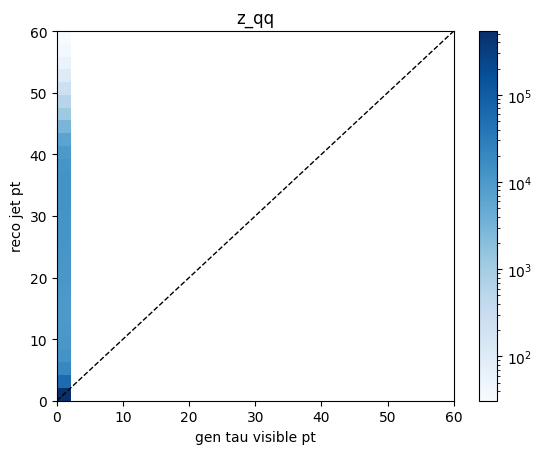

In [82]:
b = np.linspace(0,60,30)
plt.title(titles_zh)
plt.hist2d(
    ak.to_numpy(to_p4(data_zh["gen_jet_tau_p4s"]).pt),
    ak.to_numpy(to_p4(data_zh["reco_jet_p4s"]).pt),
    bins=(b,b),
    norm=matplotlib.colors.LogNorm(),
    cmap="Blues",
);
plt.colorbar()
plt.plot([0,220],[0,220], color="black", ls="--", lw=1.0)
plt.xlabel("gen tau visible pt")
plt.ylabel("reco jet pt")
# plt.savefig("zh_gen_tau_reco_jet_pT.png", bbox_inches='tight')

/opt/conda/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


Text(0, 0.5, 'matched jets / bin')

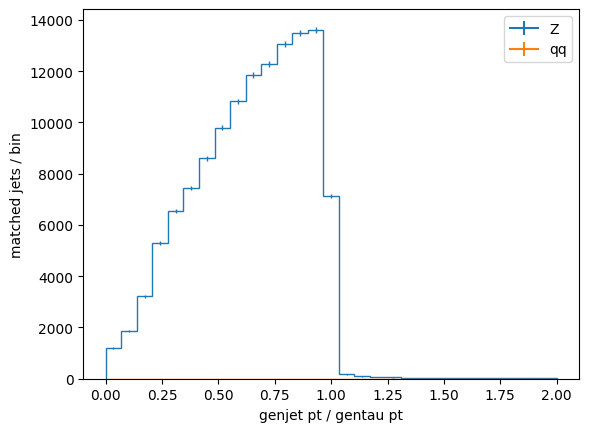

In [83]:
bins = np.linspace(0.0,2,30)

mplhep.histplot(
    to_bh(
        to_p4(data_z["gen_jet_p4s"]).pt / to_p4(data_z["gen_jet_full_tau_p4s"]).pt
    , bins=bins), histtype="step", lw=1, flow="none", label="Z"
)

mplhep.histplot(
    to_bh(
        to_p4(data_zh["gen_jet_p4s"]).pt / to_p4(data_zh["gen_jet_full_tau_p4s"]).pt
    , bins=bins), histtype="step", lw=1, flow="none", label="qq")

plt.legend(loc="best")
#plt.yscale("log")
plt.xlabel("genjet pt / gentau pt")
plt.ylabel("matched jets / bin")

/opt/conda/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


Text(0, 0.5, 'matched jets / bin')

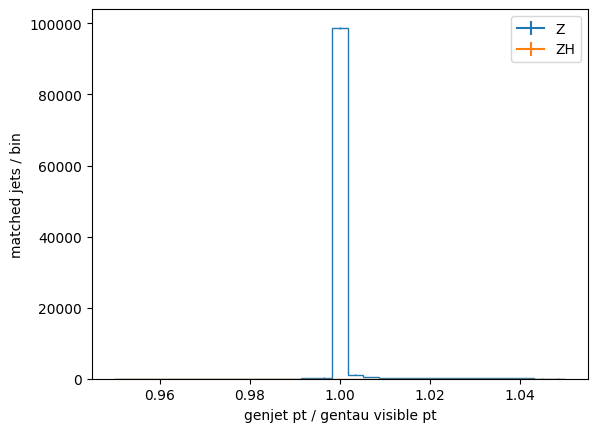

In [51]:
bins = np.linspace(0.95, 1.05, 30)

mplhep.histplot(
    to_bh(
        to_p4(data_z["gen_jet_p4s"]).pt / to_p4(data_z["gen_jet_tau_p4s"]).pt
    , bins=bins), histtype="step", lw=1, flow="none", label="Z"
)

mplhep.histplot(
    to_bh(
        to_p4(data_zh["gen_jet_p4s"]).pt / to_p4(data_zh["gen_jet_tau_p4s"]).pt
    , bins=bins), histtype="step", lw=1, flow="none", label="ZH")
plt.legend(loc="best")
#plt.yscale("log")
plt.xlabel("genjet pt / gentau visible pt")
plt.ylabel("matched jets / bin")

/opt/conda/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


Text(0, 0.5, 'matched jets / bin')

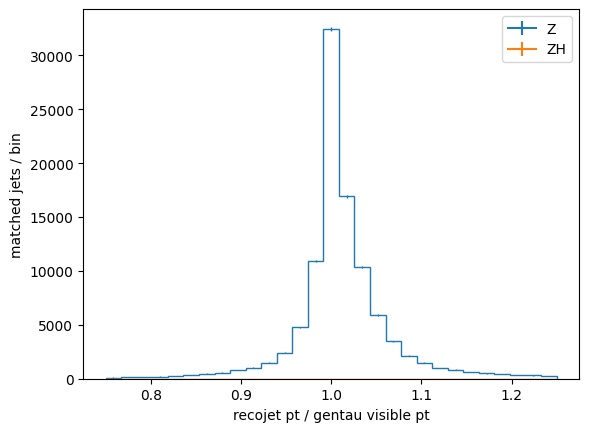

In [52]:
bins = np.linspace(0.75,1.25,30)

mplhep.histplot(
    to_bh(
        to_p4(data_z["reco_jet_p4s"]).pt / to_p4(data_z["gen_jet_tau_p4s"]).pt
    , bins=bins), histtype="step", lw=1, flow="none", label="Z")

mplhep.histplot(
    to_bh(
        to_p4(data_zh["reco_jet_p4s"]).pt / to_p4(data_zh["gen_jet_tau_p4s"]).pt
    , bins=bins), histtype="step", lw=1, flow="none", label="ZH")
plt.legend(loc="best")
#plt.yscale("log")
plt.xlabel("recojet pt / gentau visible pt")
plt.ylabel("matched jets / bin")

Text(0, 0.5, 'jets / bin')

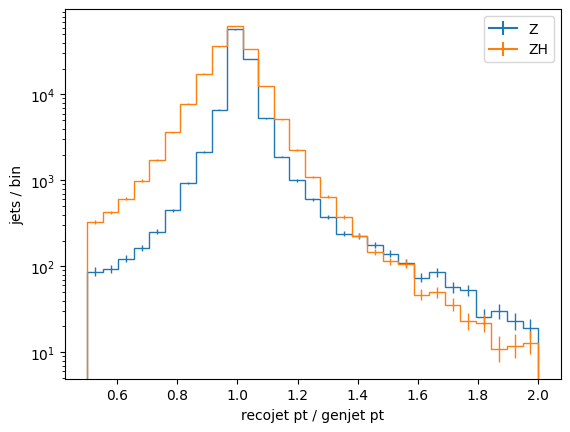

In [53]:
bins = np.linspace(0.5,2,30)

mplhep.histplot(
    to_bh(
        to_p4(data_z["reco_jet_p4s"]).pt / to_p4(data_z["gen_jet_p4s"]).pt
    , bins=bins), histtype="step", lw=1, flow="none", label="Z")

mplhep.histplot(
    to_bh(
        to_p4(data_zh["reco_jet_p4s"]).pt / to_p4(data_zh["gen_jet_p4s"]).pt
    , bins=bins), histtype="step", lw=1, flow="none", label="ZH")

plt.legend(loc="best")
plt.yscale("log")
plt.xlabel("recojet pt / genjet pt")
plt.ylabel("jets / bin")

Text(0, 0.5, 'Number of reco jets / bin')

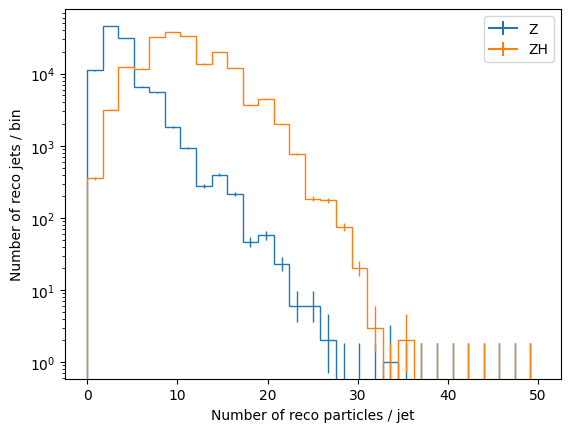

In [54]:
bins = np.linspace(0,50,30)
mplhep.histplot(to_bh(ak.num(data_z["reco_cand_p4s"]), bins=bins), histtype="step", lw=1, flow="sum", label="Z")
mplhep.histplot(to_bh(ak.num(data_zh["reco_cand_p4s"]), bins=bins), histtype="step", lw=1, flow="sum", label="ZH")
plt.legend(loc="best")
plt.yscale("log")
plt.xlabel("Number of reco particles / jet")
plt.ylabel("Number of reco jets / bin")

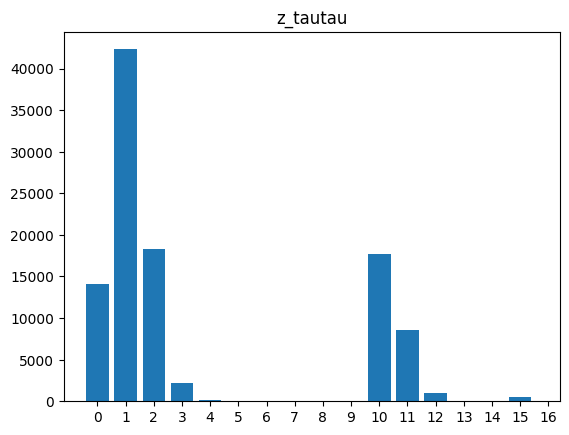

In [55]:
dms = np.arange(17)
plt.title(titles_z)
plt.hist(
    data_z["gen_jet_tau_decaymode"], bins=dms,
    width=0.8
)

plt.xticks(dms+0.4, dms);

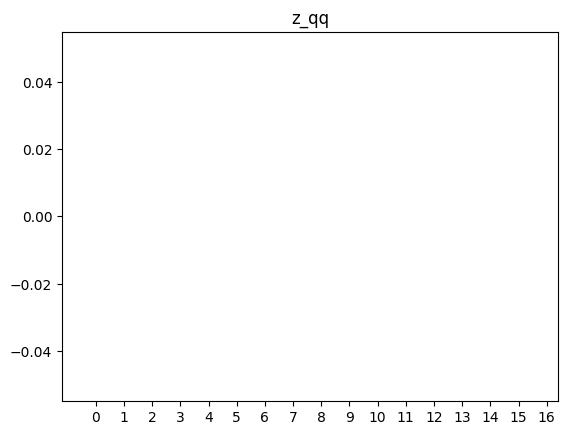

In [56]:
dms = np.arange(17)
plt.title(titles_zh)
plt.hist(
    data_zh["gen_jet_tau_decaymode"], bins=dms,
    width=0.8
)

plt.xticks(dms+0.4, dms);

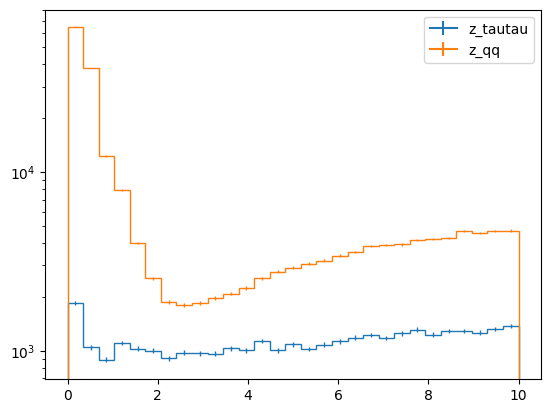

In [57]:
bins = np.linspace(0,10,30)
mplhep.histplot(to_bh(ak.flatten(data_z["reco_cand_d3"][data_z["reco_cand_charge"]!=0]), bins=bins), histtype="step", lw=1, flow="none", label=titles_z)
mplhep.histplot(to_bh(ak.flatten(data_zh["reco_cand_d3"][data_zh["reco_cand_charge"]!=0]), bins=bins), histtype="step", lw=1, flow="none", label=titles_zh)

plt.yscale("log")
plt.legend(loc="best")

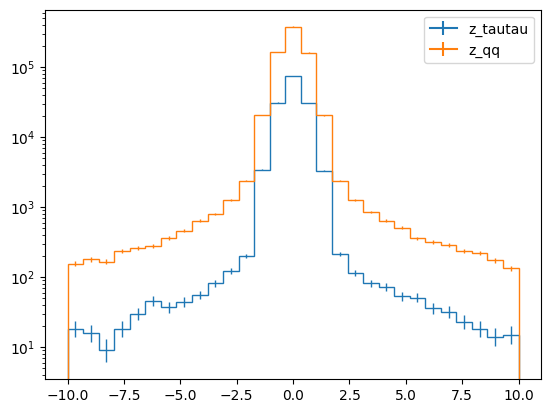

In [58]:
bins = np.linspace(-10,10,30)
mplhep.histplot(to_bh(ak.flatten(data_z["reco_cand_d0"][data_z["reco_cand_charge"]!=0]), bins=bins), histtype="step", lw=1, flow="none", label=titles_z)
mplhep.histplot(to_bh(ak.flatten(data_zh["reco_cand_d0"][data_zh["reco_cand_charge"]!=0]), bins=bins), histtype="step", lw=1, flow="none", label=titles_zh)

plt.yscale("log")
plt.legend(loc="best")

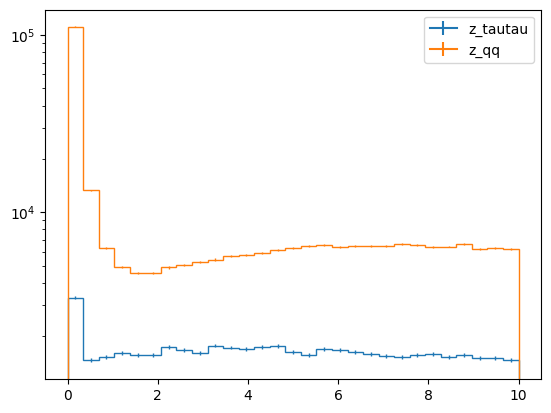

In [59]:
bins = np.linspace(0,10,30)
mplhep.histplot(to_bh(ak.flatten(data_z["reco_cand_dz"][data_z["reco_cand_charge"]!=0]), bins=bins), histtype="step", lw=1, flow="none", label=titles_z)
mplhep.histplot(to_bh(ak.flatten(data_zh["reco_cand_dz"][data_zh["reco_cand_charge"]!=0]), bins=bins), histtype="step", lw=1, flow="none", label=titles_zh)

plt.yscale("log")
plt.legend(loc="best")

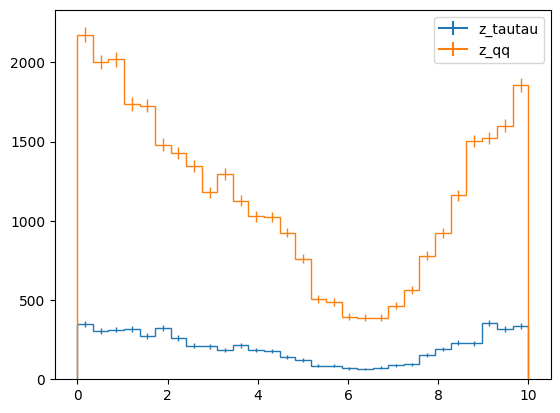

In [60]:
bins = np.linspace(0,10,30)
mplhep.histplot(to_bh(ak.flatten(data_z["reco_cand_z0"][data_z["reco_cand_charge"]!=0]), bins=bins), histtype="step", lw=1, flow="none", label=titles_z)
mplhep.histplot(to_bh(ak.flatten(data_zh["reco_cand_z0"][data_zh["reco_cand_charge"]!=0]), bins=bins), histtype="step", lw=1, flow="none", label=titles_zh)

# plt.yscale("log")
plt.legend(loc="best")

### validation plots

In [61]:
def plot_with_ratio(gen_data, reco_data, bins, range_val, xlabel, title, filename, label1, label2, color2):
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})

    #  Get and convert counts
    c_gen, bin_edges = np.histogram(gen_data, bins=bins, range=range_val)
    c_reco, _ = np.histogram(reco_data, bins=bins, range=range_val)
    counts_gen = np.asarray(c_gen, dtype=float)
    counts_reco = np.asarray(c_reco, dtype=float)

    # Main plot (top)
    ax1.hist(bin_edges[:-1], bins=bin_edges, weights=counts_gen, color='crimson', 
             histtype='step', lw=2, label=label1, alpha=0.7)
    ax1.hist(bin_edges[:-1], bins=bin_edges, weights=counts_reco, color=color2, 
             histtype='step', lw=2, label=label2, alpha=0.7)
    
    ax1.set_ylabel("Entries", fontsize=12)
    ax1.set_title(title, fontsize=14)
    ax1.legend(loc='upper right')
    ax1.grid(alpha=0.3)

    # Ratio plot (bottom)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ratio = np.divide(counts_gen, counts_reco, 
                      out=np.full_like(counts_gen, np.nan), 
                      where=counts_reco != 0)
    
    # Poisson errors
    error = ratio * np.sqrt(np.divide(1, counts_gen, out=np.zeros_like(ratio), where=counts_gen > 0) + 
                            np.divide(1, counts_reco, out=np.zeros_like(ratio), where=counts_reco > 0))

    # Mask out nans for the errorbar plot
    mask = ~np.isnan(ratio)
    ax2.errorbar(bin_centers[mask], ratio[mask], yerr=error[mask], 
                 fmt='o', color='black', markersize=4, capsize=2)
    
    ax2.axhline(1, color='gray', linestyle='--', alpha=0.7)
    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel("Ratio (Gen/Reco)", fontsize=12)
    ax2.set_ylim(0.0, 2.0) 
    ax2.grid(alpha=0.3)



    # Margins and vertical gap between the plots
    plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.92, hspace=0.08)
    
    # plt.savefig(filename) # Uncomment to save plot
    plt.show()

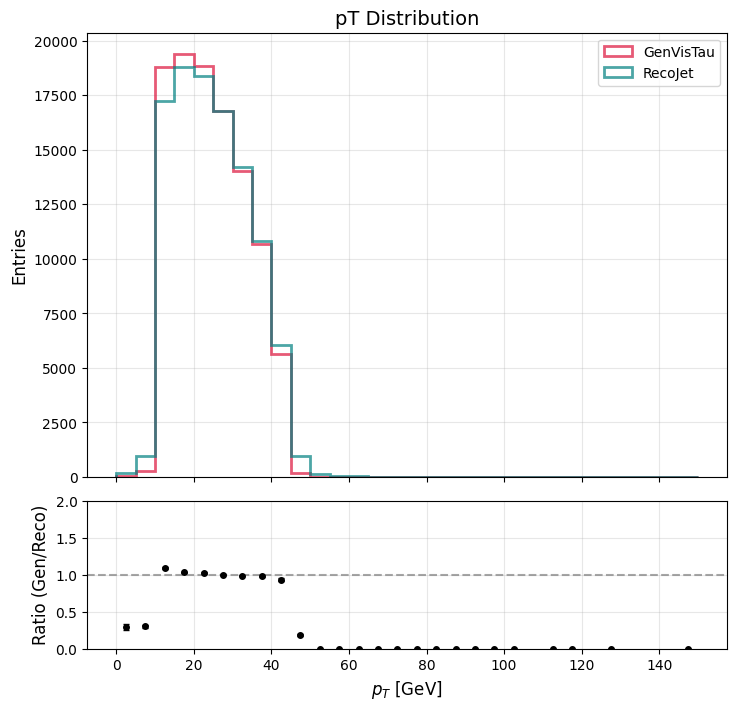

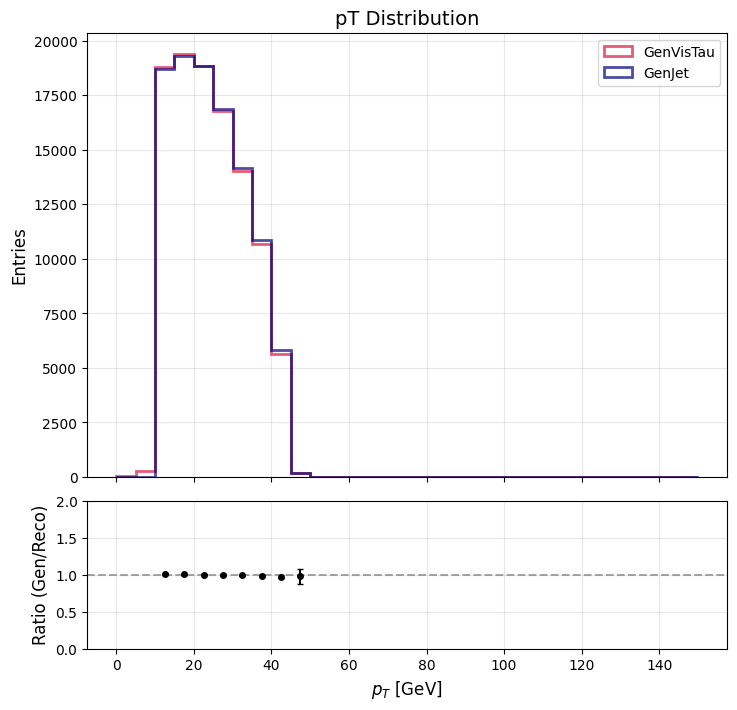

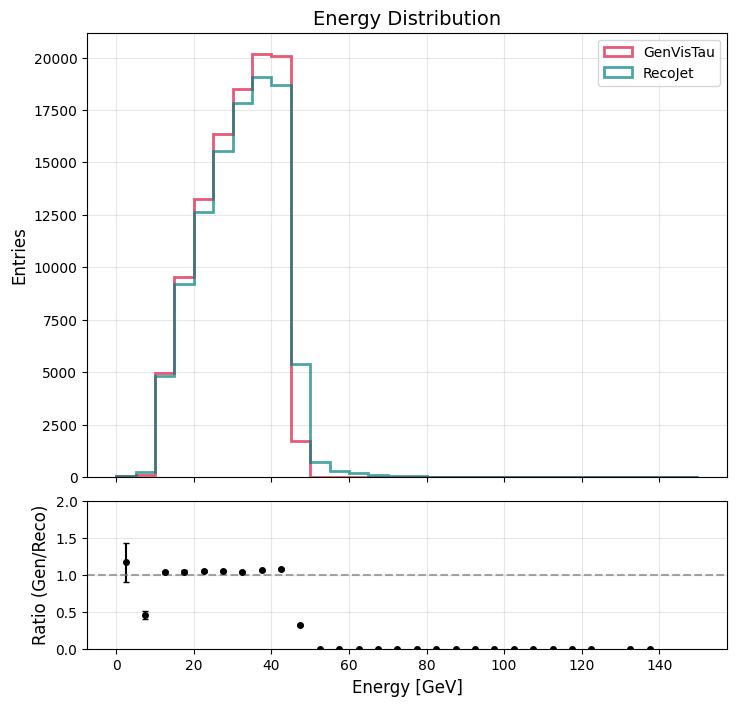

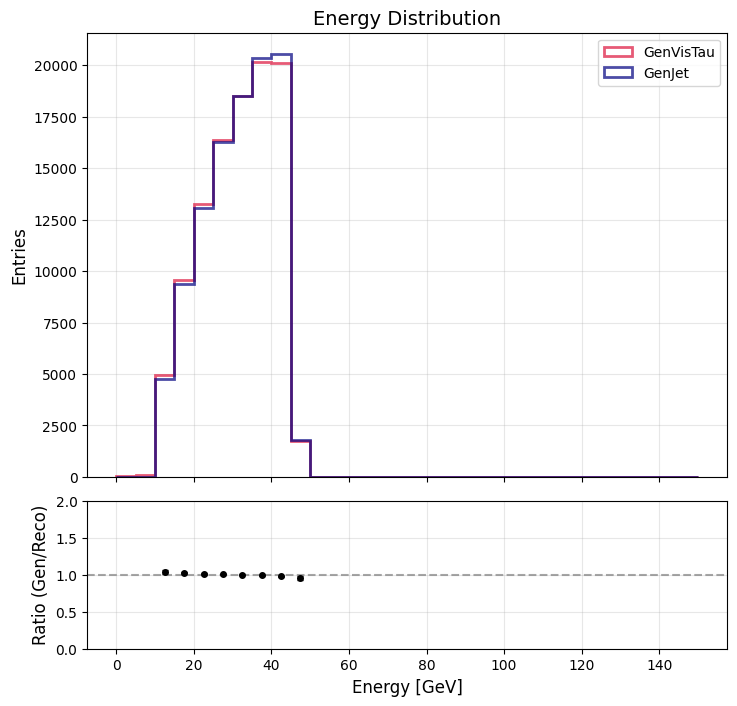

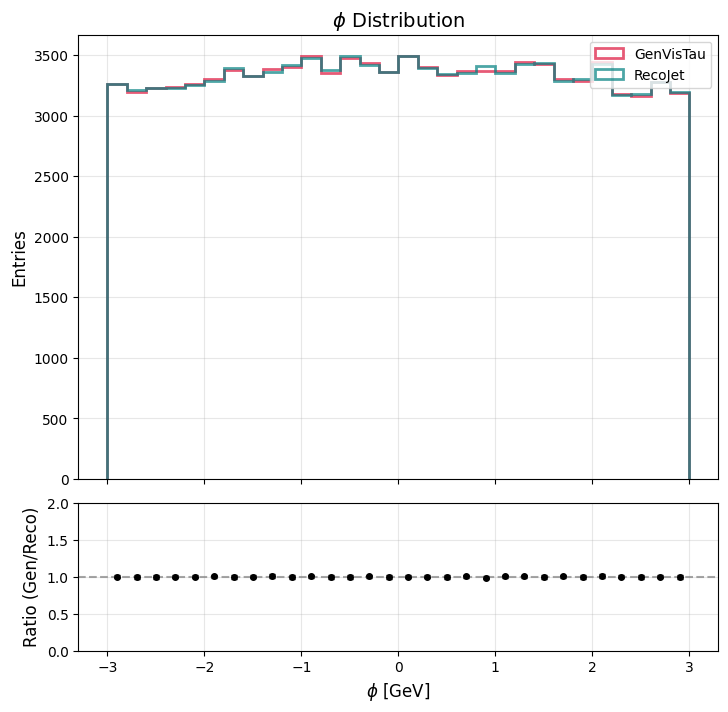

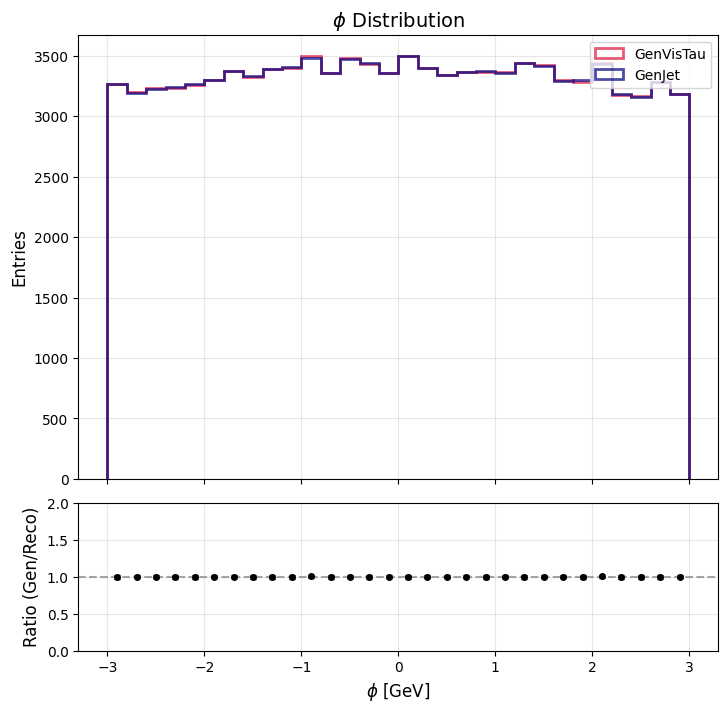

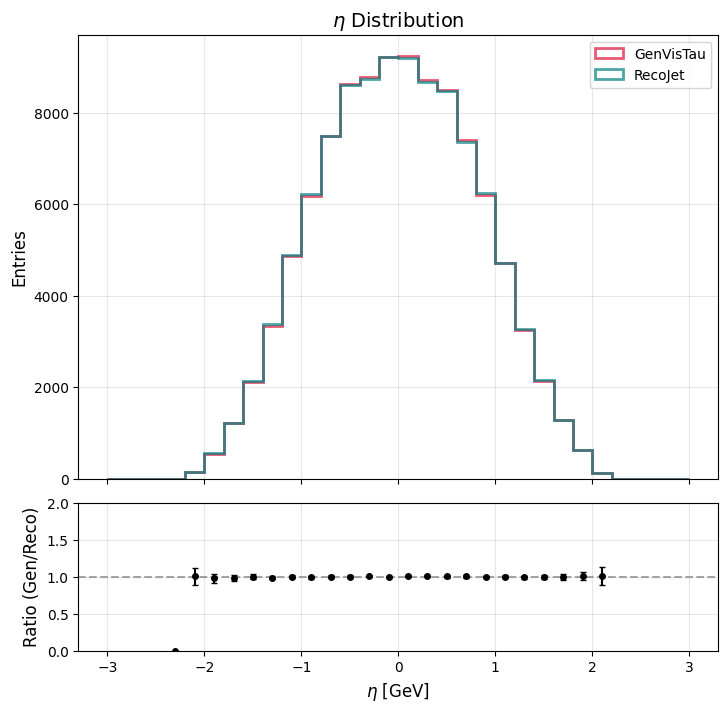

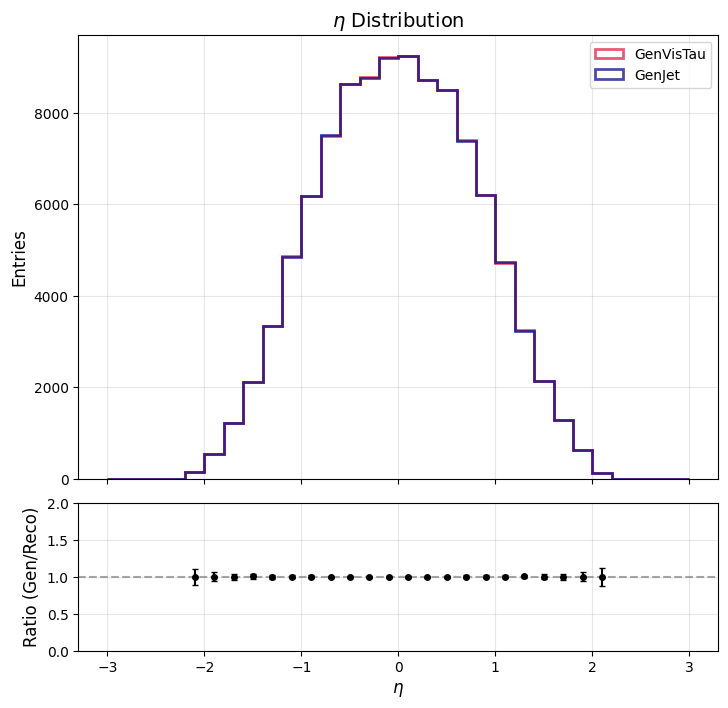

In [62]:
# pT
plot_with_ratio(to_p4(data_z["gen_jet_tau_p4s"]).pt, to_p4(data_z["reco_jet_p4s"]).pt, 30, (0, 150), 
                r"$p_{T}$ [GeV]", "pT Distribution", "pt_plot_VisTau_RecoJet.png", "GenVisTau", "RecoJet", "teal")
# pT
plot_with_ratio(to_p4(data_z["gen_jet_tau_p4s"]).pt, to_p4(data_z["gen_jet_p4s"]).pt, 30, (0, 150), 
                r"$p_{T}$ [GeV]", "pT Distribution", "pt_plot_VisTau_GenJet.png", "GenVisTau", "GenJet", "navy")

# Energy
plot_with_ratio(to_p4(data_z["gen_jet_tau_p4s"]).energy, to_p4(data_z["reco_jet_p4s"]).energy, 30, (0, 150), 
                r"Energy [GeV]", "Energy Distribution", "energy_plot_VisTau_RecoJet.png", "GenVisTau", "RecoJet", "teal")
# Energy
plot_with_ratio(to_p4(data_z["gen_jet_tau_p4s"]).energy, to_p4(data_z["gen_jet_p4s"]).energy, 30, (0, 150), 
                r"Energy [GeV]", "Energy Distribution", "energy_plot_VisTau_GenJet.png", "GenVisTau", "GenJet", "navy")

# phi
plot_with_ratio(to_p4(data_z["gen_jet_tau_p4s"]).phi, to_p4(data_z["reco_jet_p4s"]).phi, 30, (-3, 3), 
                r"$\phi$ [GeV]", "$\phi$ Distribution", "phi_plot_VisTau_RecoJet.png", "GenVisTau", "RecoJet", "teal")
# phi
plot_with_ratio(to_p4(data_z["gen_jet_tau_p4s"]).phi, to_p4(data_z["gen_jet_p4s"]).phi, 30, (-3, 3), 
                r"$\phi$ [GeV]", "$\phi$ Distribution", "phi_plot_VisTau_GenJet.png", "GenVisTau", "GenJet", "navy")

# eta
plot_with_ratio(to_p4(data_z["gen_jet_tau_p4s"]).eta, to_p4(data_z["reco_jet_p4s"]).eta, 30, (-3, 3), 
                r"$\eta$ [GeV]", "$\eta$ Distribution", "eta_plot_VisTau_RecoJet.png", "GenVisTau", "RecoJet", "teal")
# eta
plot_with_ratio(to_p4(data_z["gen_jet_tau_p4s"]).eta, to_p4(data_z["gen_jet_p4s"]).eta, 30, (-3, 3), 
                r"$\eta$", "$\eta$ Distribution", "eta_plot_VisTau_GenJet.png", "GenVisTau", "GenJet", "navy")

In [63]:
data_z.fields

['reco_cand_p4s',
 'reco_cand_charge',
 'reco_cand_pdg',
 'reco_jet_p4s',
 'reco_cand_dz',
 'reco_cand_d3',
 'reco_cand_dz_err',
 'reco_cand_d3_err',
 'reco_cand_d0',
 'reco_cand_z0',
 'reco_cand_d0_err',
 'reco_cand_z0_err',
 'gen_jet_p4s',
 'gen_jet_tau_decaymode',
 'gen_jet_tau_p4s',
 'gen_jet_full_tau_p4s']

In [64]:
ratio_pt_vistau_genjet = to_p4(data_z["gen_jet_tau_p4s"]).pt/to_p4(data_z["gen_jet_p4s"]).pt
ratio_pt_vistau_recojet = to_p4(data_z["gen_jet_tau_p4s"]).pt/to_p4(data_z["reco_jet_p4s"]).pt

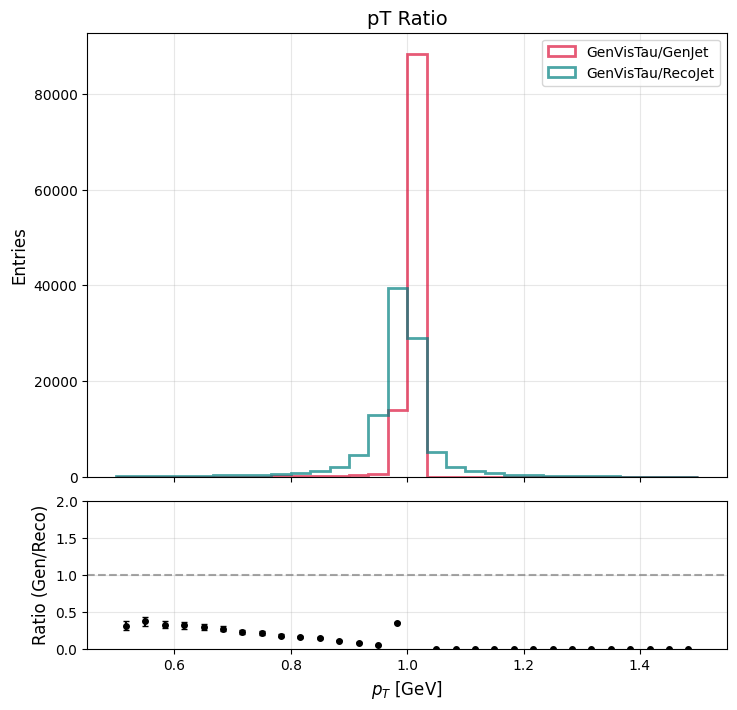

In [65]:
plot_with_ratio(ratio_pt_vistau_genjet, ratio_pt_vistau_recojet, 30, (0.5, 1.5), 
                r"$p_{T}$ [GeV]", "pT Ratio", "pt_ratio_GenVisTau_GenJet_RecoJet.png", "GenVisTau/GenJet", "GenVisTau/RecoJet", "teal")

In [66]:
def plot_without_ratio(gen_data, reco_data, bins, range_val, xlabel, title, filename,
                       label1, label2, color2):
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Get and convert counts
    c_gen, bin_edges = np.histogram(gen_data, bins=bins, range=range_val)
    c_reco, _ = np.histogram(reco_data, bins=bins, range=range_val)
    counts_gen = np.asarray(c_gen, dtype=float)
    counts_reco = np.asarray(c_reco, dtype=float)

    # Main plot
    ax.hist(
        bin_edges[:-1],
        bins=bin_edges,
        weights=counts_gen,
        color='crimson',
        histtype='step',
        lw=2,
        label=label1,
        alpha=0.7
    )

    ax.hist(
        bin_edges[:-1],
        bins=bin_edges,
        weights=counts_reco,
        color=color2,
        histtype='step',
        lw=2,
        label=label2,
        alpha=0.7
    )

    # Labels and styling
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Entries", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

    # Margins
    plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.92)

    # plt.savefig(filename)
    plt.show()


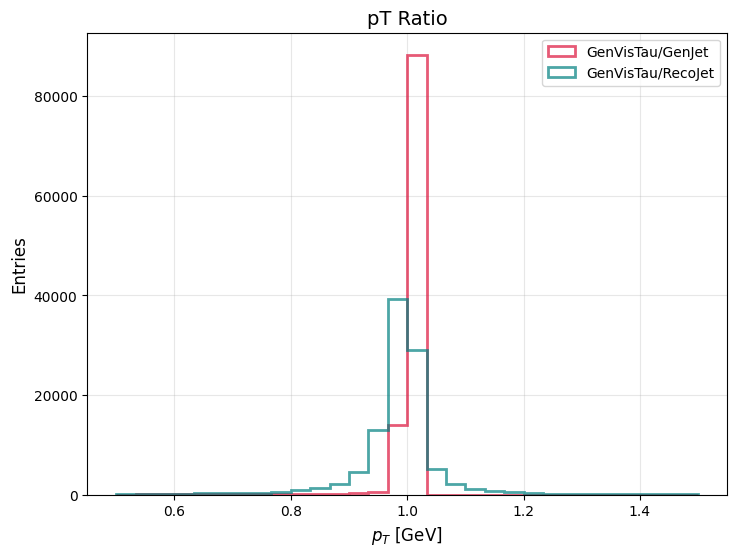

In [67]:
plot_without_ratio(ratio_pt_vistau_genjet, ratio_pt_vistau_recojet, 30, (0.5, 1.5), 
                r"$p_{T}$ [GeV]", "pT Ratio", "pt_ratio_GenVisTau_GenJet_RecoJet.png", "GenVisTau/GenJet", "GenVisTau/RecoJet", "teal")